In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/sentiment-analysis-dataset/training.1600000.processed.noemoticon.csv
/kaggle/input/sentiment-analysis-dataset/train.csv
/kaggle/input/sentiment-analysis-dataset/testdata.manual.2009.06.14.csv
/kaggle/input/sentiment-analysis-dataset/test.csv


In [2]:
original_train_df = pd.read_csv('/kaggle/input/sentiment-analysis-dataset/train.csv', encoding='ISO-8859-1')
original_test_df = pd.read_csv('/kaggle/input/sentiment-analysis-dataset/test.csv', encoding='ISO-8859-1')

### Text Cleaning

Using only text and sentiment column from both train and test data

In [3]:
original_train_df.head()

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


In [4]:
original_test_df.head()

,textID,text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,f87dea47db,Last session of the day http://twitpic.com/67ezh,neutral,morning,0-20,Afghanistan,38928346.0,652860.0,60.0
1,96d74cb729,Shanghai is also really exciting (precisely -...,positive,noon,21-30,Albania,2877797.0,27400.0,105.0
2,eee518ae67,"Recession hit Veronique Branquinho, she has to...",negative,night,31-45,Algeria,43851044.0,2381740.0,18.0
3,01082688c6,happy bday!,positive,morning,46-60,Andorra,77265.0,470.0,164.0
4,33987a8ee5,http://twitpic.com/4w75p - I like it!!,positive,noon,60-70,Angola,32866272.0,1246700.0,26.0


In [5]:
train_df = original_train_df[['text','sentiment']]
test_df = original_test_df[['text','sentiment']]

In [6]:
train_df.shape

(27481, 2)

In [7]:
test_df.shape

(4815, 2)

In [8]:
train_df['sentiment'].value_counts()

sentiment
neutral     11118
positive     8582
negative     7781
Name: count, dtype: int64

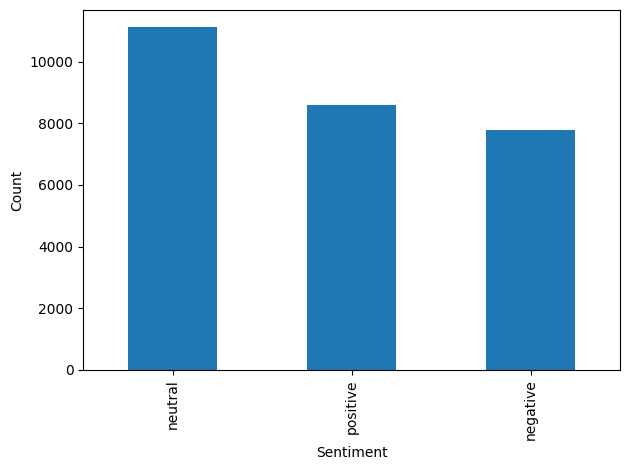

In [9]:
import matplotlib.pyplot as plt
train_df['sentiment'].value_counts().plot(kind='bar')
plt.xlabel('Sentiment')
plt.ylabel("Count")
plt.tight_layout()
plt.show()

#### Converting to lowercase

- This way, for example :“Free” and “free” will be treated as the same word, and our data analysis will be more accurate and reliable.

In [10]:
train_df = train_df.applymap(lambda x: x.lower() if isinstance(x,str) else x)

/tmp/ipykernel_13/2666690950.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  train_df = train_df.applymap(lambda x: x.lower() if isinstance(x,str) else x)


In [11]:
train_df

,text,sentiment
0,"i`d have responded, if i were going",neutral
1,sooo sad i will miss you here in san diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"sons of ****, why couldn`t they put them on t...",negative
...,...,...
27476,wish we could come see u on denver husband l...,negative
27477,i`ve wondered about rake to. the client has ...,negative
27478,yay good for both of you. enjoy the break - y...,positive
27479,but it was worth it ****.,positive


In [12]:
train_df.isnull().sum()

text         1
sentiment    0
dtype: int64

In [13]:
train_df.dropna(inplace=True)

In [14]:
train_df.isnull().sum()

text         0
sentiment    0
dtype: int64

In [15]:
test_df.isnull().sum()

text         1281
sentiment    1281
dtype: int64

In [16]:
test_df.dropna(inplace=True)

/tmp/ipykernel_13/3168796586.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.dropna(inplace=True)


In [17]:
# same for test data
test_df = test_df.applymap(lambda x: x.lower() if isinstance(x,str) else x)

/tmp/ipykernel_13/1808396445.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  test_df = test_df.applymap(lambda x: x.lower() if isinstance(x,str) else x)


#### Removing URLs

In [18]:
# Convert 'text' to string to avoid errors with NaN (float) values
train_df['text'] = train_df['text'].astype(str)
test_df['text'] = test_df['text'].astype(str)

In [19]:
train_df

,text,sentiment
0,"i`d have responded, if i were going",neutral
1,sooo sad i will miss you here in san diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"sons of ****, why couldn`t they put them on t...",negative
...,...,...
27476,wish we could come see u on denver husband l...,negative
27477,i`ve wondered about rake to. the client has ...,negative
27478,yay good for both of you. enjoy the break - y...,positive
27479,but it was worth it ****.,positive


In [20]:
import re

# Defining regex pattern to match URLs
url_pattern = re.compile(f'https?://\S+')

def remove_urls(text):
    return url_pattern.sub("",text)

In [21]:
train_df['text'] = train_df['text'].apply(remove_urls)

In [22]:
test_df['text'] = test_df['text'].apply(remove_urls)

Removing non-word and non-whitespace characters

In [23]:
train_df = train_df.replace(to_replace=r'[^\w\s]',value='',regex=True)
test_df = test_df.replace(to_replace=r'[^\w\s]',value='',regex=True)

In [24]:
train_df

,text,sentiment
0,id have responded if i were going,neutral
1,sooo sad i will miss you here in san diego,negative
2,my boss is bullying me,negative
3,what interview leave me alone,negative
4,sons of why couldnt they put them on the rel...,negative
...,...,...
27476,wish we could come see u on denver husband l...,negative
27477,ive wondered about rake to the client has ma...,negative
27478,yay good for both of you enjoy the break you...,positive
27479,but it was worth it,positive


Removing digits

- In most cases, numerical values don't provide any significant meaning to the text analysis process.

In [25]:
train_df = train_df.replace(to_replace=r'\d',value='',regex=True)
test_df = test_df.replace(to_replace=r'\d',value='',regex=True)

#### Tokenization

- Tokenization is the process of breaking down large blocks of text such as paragraphs and sentences into smaller, more manageable units.

  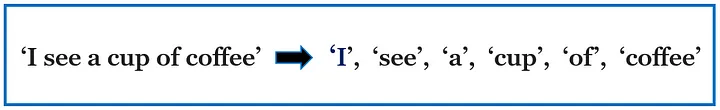
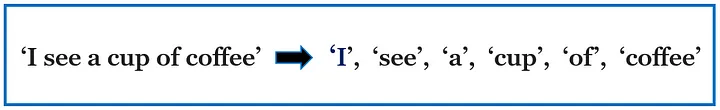

In [26]:
import nltk
from nltk.tokenize import word_tokenize

train_df['text'] = train_df['text'].apply(word_tokenize)

In [27]:
test_df['text'] = test_df['text'].apply(word_tokenize)

In [28]:
test_df

,text,sentiment
0,"[last, session, of, the, day]",neutral
1,"[shanghai, is, also, really, exciting, precise...",positive
2,"[recession, hit, veronique, branquinho, she, h...",negative
3,"[happy, bday]",positive
4,"[i, like, it]",positive
...,...,...
3529,"[its, at, am, im, very, tired, but, i, cant, s...",negative
3530,"[all, alone, in, this, old, house, again, than...",positive
3531,"[i, know, what, you, mean, my, little, dog, is...",negative
3532,"[_sutra, what, is, your, next, youtube, video,...",positive


### Stopword Removal

- Stopwords refer to the most commonly occurring words in any natural language.

  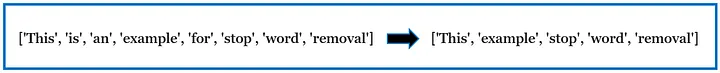
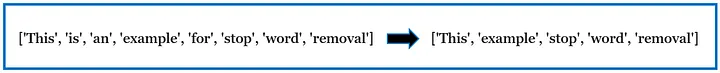

In [29]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

In [30]:
for idx,i in enumerate(stop_words):
    print(i)
    if idx == 20:
        break

she'll
is
very
about
off
between
he's
we've
into
isn't
their
weren
out
again
theirs
he
most
hers
should
should've
some


In [31]:
train_df['text'] = train_df['text'].apply(lambda x: [word for word in x if word not in stop_words])
test_df['text'] = test_df['text'].apply(lambda x: [word for word in x if word not in stop_words])

In [32]:
train_df

,text,sentiment
0,"[id, responded, going]",neutral
1,"[sooo, sad, miss, san, diego]",negative
2,"[boss, bullying]",negative
3,"[interview, leave, alone]",negative
4,"[sons, couldnt, put, releases, already, bought]",negative
...,...,...
27476,"[wish, could, come, see, u, denver, husband, l...",negative
27477,"[ive, wondered, rake, client, made, clear, net...",negative
27478,"[yay, good, enjoy, break, probably, need, hect...",positive
27479,[worth],positive


#### Stemming
Stemming is a rule-based heuristic process that chops off the ends of words (suffixes) to get to a "stem." It's a faster and simpler method, but it doesn't always result in a linguistically correct or meaningful word. It's like a blunt instrument that just cuts off the end.

Example:

"running" -> "run"
"jumps" -> "jump"
"studies" -> "studi" (This isn't a real word, but it's the stem)
"universal" -> "univers" (Again, not a real word)


In [33]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

def stem_words(words):
    return [stemmer.stem(word) for word in words]

train_df['stemmed_text'] = train_df['text'].apply(stem_words)
test_df['stemmed_text'] = test_df['text'].apply(stem_words)

In [34]:
train_df

,text,sentiment,stemmed_text
0,"[id, responded, going]",neutral,"[id, respond, go]"
1,"[sooo, sad, miss, san, diego]",negative,"[sooo, sad, miss, san, diego]"
2,"[boss, bullying]",negative,"[boss, bulli]"
3,"[interview, leave, alone]",negative,"[interview, leav, alon]"
4,"[sons, couldnt, put, releases, already, bought]",negative,"[son, couldnt, put, releas, alreadi, bought]"
...,...,...,...
27476,"[wish, could, come, see, u, denver, husband, l...",negative,"[wish, could, come, see, u, denver, husband, l..."
27477,"[ive, wondered, rake, client, made, clear, net...",negative,"[ive, wonder, rake, client, made, clear, net, ..."
27478,"[yay, good, enjoy, break, probably, need, hect...",positive,"[yay, good, enjoy, break, probabl, need, hecti..."
27479,[worth],positive,[worth]


#### Lemmatization

Lemmatization is a more sophisticated and linguistically informed process. It aims to return the base or dictionary form of a word, known as a "lemma." It does this by considering the word's morphological analysis and often uses a dictionary or a lexical database (like WordNet) to ensure the resulting lemma is a valid word. It also often takes into account the part-of-speech (POS) of the word to determine the correct lemma.

Example:

"running" -> "run"
"ran" -> "run"
"better" -> "good" (Here, it correctly identifies the root as "good" because it understands the meaning)
"geese" -> "goose"
"mice" -> "mouse"
"meeting" (noun) -> "meeting"
"meeting" (verb, as in "We are meeting") -> "meet"


In [35]:
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('all')

from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /usr/share/nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to /usr/share/nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /usr/share/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /usr/s

In [36]:
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    def get_wordnet_pos(word):
        tag = nltk.pos_tag([word])[0][1][0].upper()
        tag_dict = {
            "J": wordnet.ADJ,
            "N": wordnet.NOUN,
            "V": wordnet.VERB,
            "R": wordnet.ADV
        }
        return tag_dict.get(tag,wordnet.NOUN)

    lemmas = [lemmatizer.lemmatize(token,get_wordnet_pos(token)) for token in tokens]
    return lemmas


In [37]:
train_df['lemmatized_text'] = train_df['text'].apply(lemmatize_tokens)


In [38]:
train_df

,text,sentiment,stemmed_text,lemmatized_text
0,"[id, responded, going]",neutral,"[id, respond, go]","[id, respond, go]"
1,"[sooo, sad, miss, san, diego]",negative,"[sooo, sad, miss, san, diego]","[sooo, sad, miss, san, diego]"
2,"[boss, bullying]",negative,"[boss, bulli]","[bos, bullying]"
3,"[interview, leave, alone]",negative,"[interview, leav, alon]","[interview, leave, alone]"
4,"[sons, couldnt, put, releases, already, bought]",negative,"[son, couldnt, put, releas, alreadi, bought]","[son, couldnt, put, release, already, bought]"
...,...,...,...,...
27476,"[wish, could, come, see, u, denver, husband, l...",negative,"[wish, could, come, see, u, denver, husband, l...","[wish, could, come, see, u, denver, husband, l..."
27477,"[ive, wondered, rake, client, made, clear, net...",negative,"[ive, wonder, rake, client, made, clear, net, ...","[ive, wonder, rake, client, make, clear, net, ..."
27478,"[yay, good, enjoy, break, probably, need, hect...",positive,"[yay, good, enjoy, break, probabl, need, hecti...","[yay, good, enjoy, break, probably, need, hect..."
27479,[worth],positive,[worth],[worth]


In [39]:
test_df['lemmatized_text'] = test_df['text'].apply(lemmatize_tokens)


In [40]:
train_df['sentiment'].value_counts()

sentiment
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64

In [41]:
## Sentement Mapping
sentiment_mapping = {'negative':0,'positive':1,'neutral':2}
train_df['sentiment']= train_df['sentiment'].map(sentiment_mapping)
test_df['sentiment'] = test_df['sentiment'].map(sentiment_mapping)

In [42]:
train_df.head()

,text,sentiment,stemmed_text,lemmatized_text
0,"[id, responded, going]",2,"[id, respond, go]","[id, respond, go]"
1,"[sooo, sad, miss, san, diego]",0,"[sooo, sad, miss, san, diego]","[sooo, sad, miss, san, diego]"
2,"[boss, bullying]",0,"[boss, bulli]","[bos, bullying]"
3,"[interview, leave, alone]",0,"[interview, leav, alon]","[interview, leave, alone]"
4,"[sons, couldnt, put, releases, already, bought]",0,"[son, couldnt, put, releas, alreadi, bought]","[son, couldnt, put, release, already, bought]"


In [43]:
test_df['sentiment'].value_counts()

sentiment
2    1430
1    1103
0    1001
Name: count, dtype: int64

Preparing text for vectorization

In [44]:
train_df['processed_text'] = train_df['lemmatized_text'].apply(lambda x: ' '.join(x))
test_df['processed_text'] = test_df['lemmatized_text'].apply(lambda x: ' '.join(x))

In [45]:
# Separating features and target
X_train = train_df['processed_text']
y_train = train_df['sentiment']
X_test = test_df['processed_text']
y_test = test_df['sentiment']

In [46]:
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 27480
Testing samples: 3534


In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
import seaborn as sns

In [48]:
def train_and_evaluate_model(X_train_features, X_test_features, y_train, y_test, model_name, target_names=None):
    print(f"Training Logistic Regression with {model_name} ---")
    model = LogisticRegression(max_iter=1000, solver='liblinear') # Increased max_iter for convergence
    model.fit(X_train_features, y_train)

    y_pred = model.predict(X_test_features)

    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    # Using 'weighted' average for precision, recall, f1-score due to potential multi-class/imbalance
    print(f"Precision: {precision_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test,y_pred)
    print(cm)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=label_names,yticklabels=label_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()
    print("\nClassification Report:")
    # Pass target_names if you want to see specific class labels in the report
    print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))

In [49]:
unique_labels = sorted(train_df['sentiment'].unique())
# Reverse map for target names if needed, or just use string labels
# E.g., if sentiment_mapping = {'positive': 1, 'negative': 0, 'neutral': 2}
# label_names = ['negative', 'positive', 'neutral'] based on 0, 1, 2
label_names = [k for k, v in sorted(sentiment_mapping.items(), key=lambda item: item[1])]

In [50]:
label_names

['negative', 'positive', 'neutral']


--- Running Experiment 1: Bag-of-Words ---
Training Logistic Regression with Bag-of-Words ---
Accuracy: 0.7060
Precision: 0.7106
Recall: 0.7060
F1-Score: 0.7069

Confusion Matrix:
[[ 655   42  304]
 [  45  806  252]
 [ 226  170 1034]]


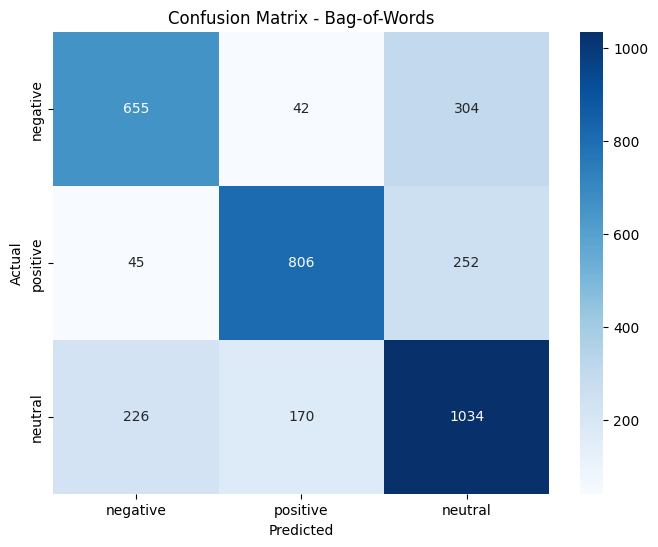


Classification Report:
              precision    recall  f1-score   support

    negative       0.71      0.65      0.68      1001
    positive       0.79      0.73      0.76      1103
     neutral       0.65      0.72      0.68      1430

    accuracy                           0.71      3534
   macro avg       0.72      0.70      0.71      3534
weighted avg       0.71      0.71      0.71      3534



In [51]:
# --- Experiment 1: Bag-of-Words (BoW) ---
print("\n--- Running Experiment 1: Bag-of-Words ---")
vectorizer_bow = CountVectorizer()
X_train_bow = vectorizer_bow.fit_transform(X_train)
X_test_bow = vectorizer_bow.transform(X_test)
train_and_evaluate_model(X_train_bow, X_test_bow, y_train, y_test, "Bag-of-Words", target_names=label_names)



--- Running Experiment 2: TF-IDF ---
Training Logistic Regression with TF-IDF ---
Accuracy: 0.7060
Precision: 0.7150
Recall: 0.7060
F1-Score: 0.7068

Confusion Matrix:
[[ 624   37  340]
 [  36  796  271]
 [ 200  155 1075]]


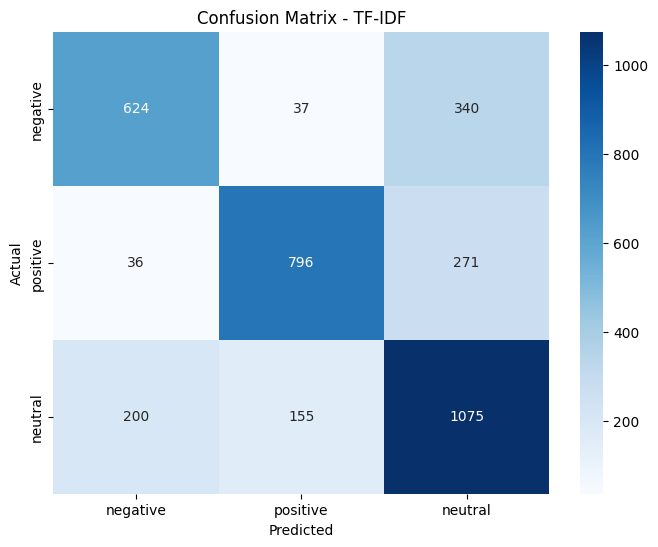


Classification Report:
              precision    recall  f1-score   support

    negative       0.73      0.62      0.67      1001
    positive       0.81      0.72      0.76      1103
     neutral       0.64      0.75      0.69      1430

    accuracy                           0.71      3534
   macro avg       0.72      0.70      0.71      3534
weighted avg       0.71      0.71      0.71      3534



In [52]:
# --- Experiment 2: TF-IDF ---
print("\n--- Running Experiment 2: TF-IDF ---")
vectorizer_tfidf = TfidfVectorizer()
X_train_tfidf = vectorizer_tfidf.fit_transform(X_train)
X_test_tfidf = vectorizer_tfidf.transform(X_test)
train_and_evaluate_model(X_train_tfidf, X_test_tfidf, y_train, y_test, "TF-IDF", target_names=label_names)

In [53]:
import gensim.downloader as api

# Also keep the tokenized lists for word embeddings
X_train_tokens = train_df['lemmatized_text']
X_test_tokens = test_df['lemmatized_text']


In [54]:
X_train_tokens

0                                        [id, respond, go]
1                            [sooo, sad, miss, san, diego]
2                                          [bos, bullying]
3                                [interview, leave, alone]
4            [son, couldnt, put, release, already, bought]
                               ...                        
27476    [wish, could, come, see, u, denver, husband, l...
27477    [ive, wonder, rake, client, make, clear, net, ...
27478    [yay, good, enjoy, break, probably, need, hect...
27479                                              [worth]
27480                    [flirt, go, atg, smile, yay, hug]
Name: lemmatized_text, Length: 27480, dtype: object


--- Running Experiment 3: Word Embeddings ---
Loading pre-trained GloVe embeddings (glove-wiki-gigaword-50)...
[==================================================] 100.0% 66.0/66.0MB downloaded
GloVe embeddings loaded. Dimension: 50
Generating document embeddings for training data...
Generating document embeddings for test data...
Training Logistic Regression with Word Embeddings (Averaged GloVe) ---
Accuracy: 0.5693
Precision: 0.5753
Recall: 0.5693
F1-Score: 0.5670

Confusion Matrix:
[[449 111 441]
 [ 91 626 386]
 [244 249 937]]


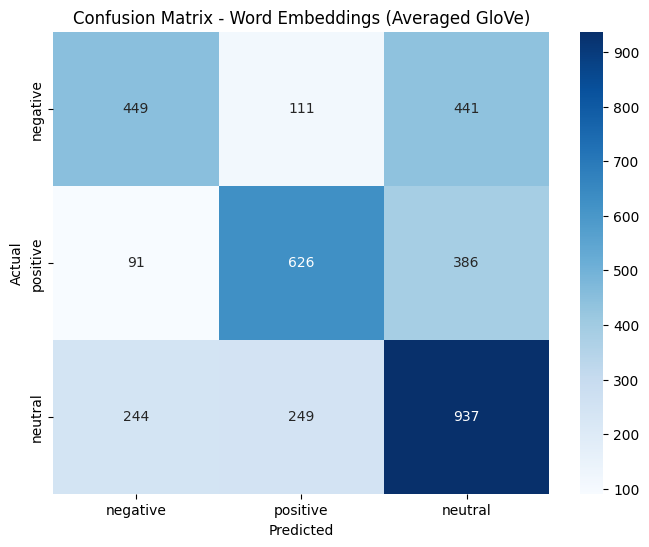


Classification Report:
              precision    recall  f1-score   support

    negative       0.57      0.45      0.50      1001
    positive       0.63      0.57      0.60      1103
     neutral       0.53      0.66      0.59      1430

    accuracy                           0.57      3534
   macro avg       0.58      0.56      0.56      3534
weighted avg       0.58      0.57      0.57      3534


--- End of Experiments ---


In [55]:
# --- Experiment 3: Word Embeddings (Word2Vec/GloVe) ---
print("\n--- Running Experiment 3: Word Embeddings ---")

try:
    print("Loading pre-trained GloVe embeddings (glove-wiki-gigaword-50)...")
    wv = api.load('glove-wiki-gigaword-50')
    embedding_dim = wv.vector_size
    print(f"GloVe embeddings loaded. Dimension: {embedding_dim}")

    def get_document_embedding_from_tokens(tokens, word_vectors, vector_dim):
        valid_embeddings = []
        for word in tokens:
            if word in word_vectors:
                valid_embeddings.append(word_vectors[word])
        if valid_embeddings:
            return np.mean(valid_embeddings, axis=0)
        else:
            return np.zeros(vector_dim) # Return a zero vector for documents with no known words

    print("Generating document embeddings for training data...")
    X_train_embeddings = np.array([get_document_embedding_from_tokens(tokens, wv, embedding_dim) for tokens in X_train_tokens])
    print("Generating document embeddings for test data...")
    X_test_embeddings = np.array([get_document_embedding_from_tokens(tokens, wv, embedding_dim) for tokens in X_test_tokens])

    X_train_embeddings[np.isnan(X_train_embeddings)] = 0
    X_test_embeddings[np.isnan(X_test_embeddings)] = 0

    train_and_evaluate_model(X_train_embeddings, X_test_embeddings, y_train, y_test, "Word Embeddings (Averaged GloVe)", target_names=label_names)

except Exception as e:
    print(f"Could not load or use word embeddings. Error: {e}")
  
print("\n--- End of Experiments ---")

In [56]:
wv = api.load('word2vec-google-news-300')

embedding_dim = wv.vector_size
print(f"Word2Vec embeddings loaded. Dimension: {embedding_dim}")


[==================================================] 100.0% 1662.8/1662.8MB downloaded
Word2Vec embeddings loaded. Dimension: 300


Generating document embeddings for training data...
Generating document embeddings for test data...
Training Logistic Regression with Word Embeddings (Averaged Word2Vec) ---
Accuracy: 0.6735
Precision: 0.6795
Recall: 0.6735
F1-Score: 0.6739

Confusion Matrix:
[[ 611   62  328]
 [  64  744  295]
 [ 225  180 1025]]


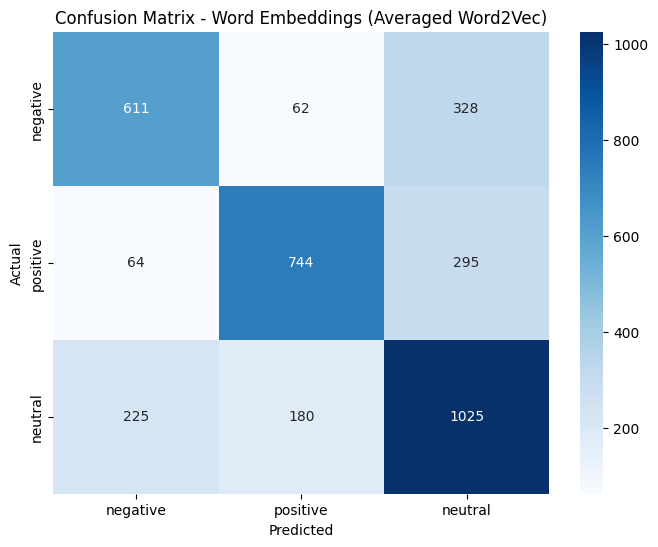


Classification Report:
              precision    recall  f1-score   support

    negative       0.68      0.61      0.64      1001
    positive       0.75      0.67      0.71      1103
     neutral       0.62      0.72      0.67      1430

    accuracy                           0.67      3534
   macro avg       0.69      0.67      0.67      3534
weighted avg       0.68      0.67      0.67      3534



In [57]:
print("Generating document embeddings for training data...")
X_train_embeddings = np.array([get_document_embedding_from_tokens(tokens, wv, embedding_dim) for tokens in X_train_tokens])
print("Generating document embeddings for test data...")
X_test_embeddings = np.array([get_document_embedding_from_tokens(tokens, wv, embedding_dim) for tokens in X_test_tokens])

# Ensure no NaNs remain (though np.zeros should handle empty documents)
X_train_embeddings[np.isnan(X_train_embeddings)] = 0
X_test_embeddings[np.isnan(X_test_embeddings)] = 0

train_and_evaluate_model(X_train_embeddings, X_test_embeddings, y_train, y_test, "Word Embeddings (Averaged Word2Vec)", target_names=label_names)